# Vues par semaine — générique vs. personnalisées (Σ conventions collectives)

Playground interactif pour comparer, par contribution, les vues hebdomadaires de
la page **générique** et la **somme** des vues de toutes les pages **personnalisées**
(une par convention collective). Les URLs personnalisées sont raccordées de part et
d'autre de la migration de slugs (schéma plat `/contribution/{idcc}-{slug}` **et**
imbriqué `/contribution/{slug}/{idcc}-{cc}`), pour que chaque courbe reste continue.

**Comment tester :** édite la cellule *Paramètres* ci-dessous (dates, métrique,
`DEMO`, ou la liste `CONTRIBUTIONS`), puis relance les cellules (`Shift+Enter`).
Source live = API Matomo (lit `MATOMO_*` depuis `analysis/.env`).

In [1]:
# Recharge automatiquement le code modifié du module (évite de devoir redémarrer
# le kernel à chaque édition de contrib_weekly_views.py).
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
from datetime import date

from analysis.reports.contrib_weekly_views import (
    CONTRIBUTIONS,
    METRICS,
    aggregate_weeks,
    build_chart,
    build_demo_data,
    decline_table,
    fetch_live,
    weekly_comparison,
)

# Afficher TOUTES les lignes / colonnes des tableaux (aucune troncature "...").
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# ── Paramètres — édite puis relance les cellules ────────────────────────────
START = "2024-09-01"
END = date.today().isoformat()
METRIC = "views"  # "views" (pageviews) | "visits"
DEMO = False  # True = données synthétiques instantanées (aucun appel Matomo)

metric_field, metric_label = METRICS[METRIC]
[(c.key, c.label, c.generic_slug) for c in CONTRIBUTIONS]

[('retraite',
  'Indemnités départ à la retraite',
  'a-quelles-indemnites-peut-pretendre-un-salarie-qui-part-a-la-retraite'),
 ('conges',
  'Congés pour événements familiaux',
  'les-conges-pour-evenements-familiaux')]

## 1. Récupération + agrégation

⏳ **Le 1er appel Matomo prend ~2-3 min** (~100 semaines) et affiche un message de
progression — la cellule n'est **pas** figée. Le résultat est **mis en cache** sur
disque : les exécutions suivantes (autre métrique, graphe, tableaux) sont instantanées.
Pour un aperçu immédiat sans Matomo, mets `DEMO = True` dans les paramètres.

In [2]:
weeks = build_demo_data() if DEMO else fetch_live(START, END)
df = aggregate_weeks(weeks, metric_field)
print(f"{len(df)} semaines : {df['week'].iloc[0]} → {df['week'].iloc[-1]}")
df  # tableau brut complet — toutes les semaines s'affichent

• Cache Matomo: pageurls_2024-09-01_2026-07-03.pkl
97 semaines : 2024-08-26 → 2026-06-29


,week,retraite_generic,retraite_perso,conges_generic,conges_perso
0,2024-08-26,3139.0,2428.0,5132.0,22796.0
1,2024-09-02,3238.0,2693.0,4902.0,19734.0
2,2024-09-09,2970.0,2618.0,4406.0,15871.0
3,2024-09-16,3262.0,2635.0,5463.0,20065.0
4,2024-09-23,3804.0,2946.0,6048.0,21154.0
5,2024-09-30,3398.0,3023.0,6054.0,22157.0
6,2024-10-07,2999.0,2543.0,6195.0,22992.0
7,2024-10-14,2821.0,2471.0,6329.0,21890.0
8,2024-10-21,2708.0,2565.0,6362.0,21853.0
9,2024-10-28,2485.0,2310.0,5798.0,19679.0


## 2. Comparaison des baisses (pic → dernière semaine)

In [3]:
decline_table(df)

,série,pic,semaine du pic,dernière (2026-06-29),baisse pic→dernière
0,Indemnités départ à la retraite — générique,7258,2026-03-23,3084,-58%
1,Indemnités départ à la retraite — perso (Σ CC),7547,2025-06-23,2978,-61%
2,Congés pour événements familiaux — générique,18389,2026-03-30,5338,-71%
3,Congés pour événements familiaux — perso (Σ CC),47394,2025-08-25,13575,-71%


### … et semaine par semaine (toutes les semaines)

Pour chaque contribution : `générique`, `perso Σ` (somme des CC), `total`, et la
variation hebdomadaire du total (`Δ%/sem`, négatif = baisse). Toutes les semaines
sont listées — utile pour comparer les baisses semaine après semaine.

In [4]:
# Semaine par semaine : toutes les semaines s'affichent (max_rows réglé plus haut).
weekly_comparison(df)

,semaine,retraite générique,retraite perso Σ,retraite total,retraite Δ%/sem,conges générique,conges perso Σ,conges total,conges Δ%/sem
0,2024-08-26,3139,2428,5567,NaN,5132,22796,27928,NaN
1,2024-09-02,3238,2693,5931,6.5,4902,19734,24636,-11.8
2,2024-09-09,2970,2618,5588,-5.8,4406,15871,20277,-17.7
3,2024-09-16,3262,2635,5897,5.5,5463,20065,25528,25.9
4,2024-09-23,3804,2946,6750,14.5,6048,21154,27202,6.6
5,2024-09-30,3398,3023,6421,-4.9,6054,22157,28211,3.7
6,2024-10-07,2999,2543,5542,-13.7,6195,22992,29187,3.5
7,2024-10-14,2821,2471,5292,-4.5,6329,21890,28219,-3.3
8,2024-10-21,2708,2565,5273,-0.4,6362,21853,28215,-0.0
9,2024-10-28,2485,2310,4795,-9.1,5798,19679,25477,-9.7


## 3. Graphe

Panneau du haut : vues absolues par semaine. Panneau du bas : chaque série indexée
à 100 à son propre pic, pour comparer la *forme* des baisses indépendamment du volume.

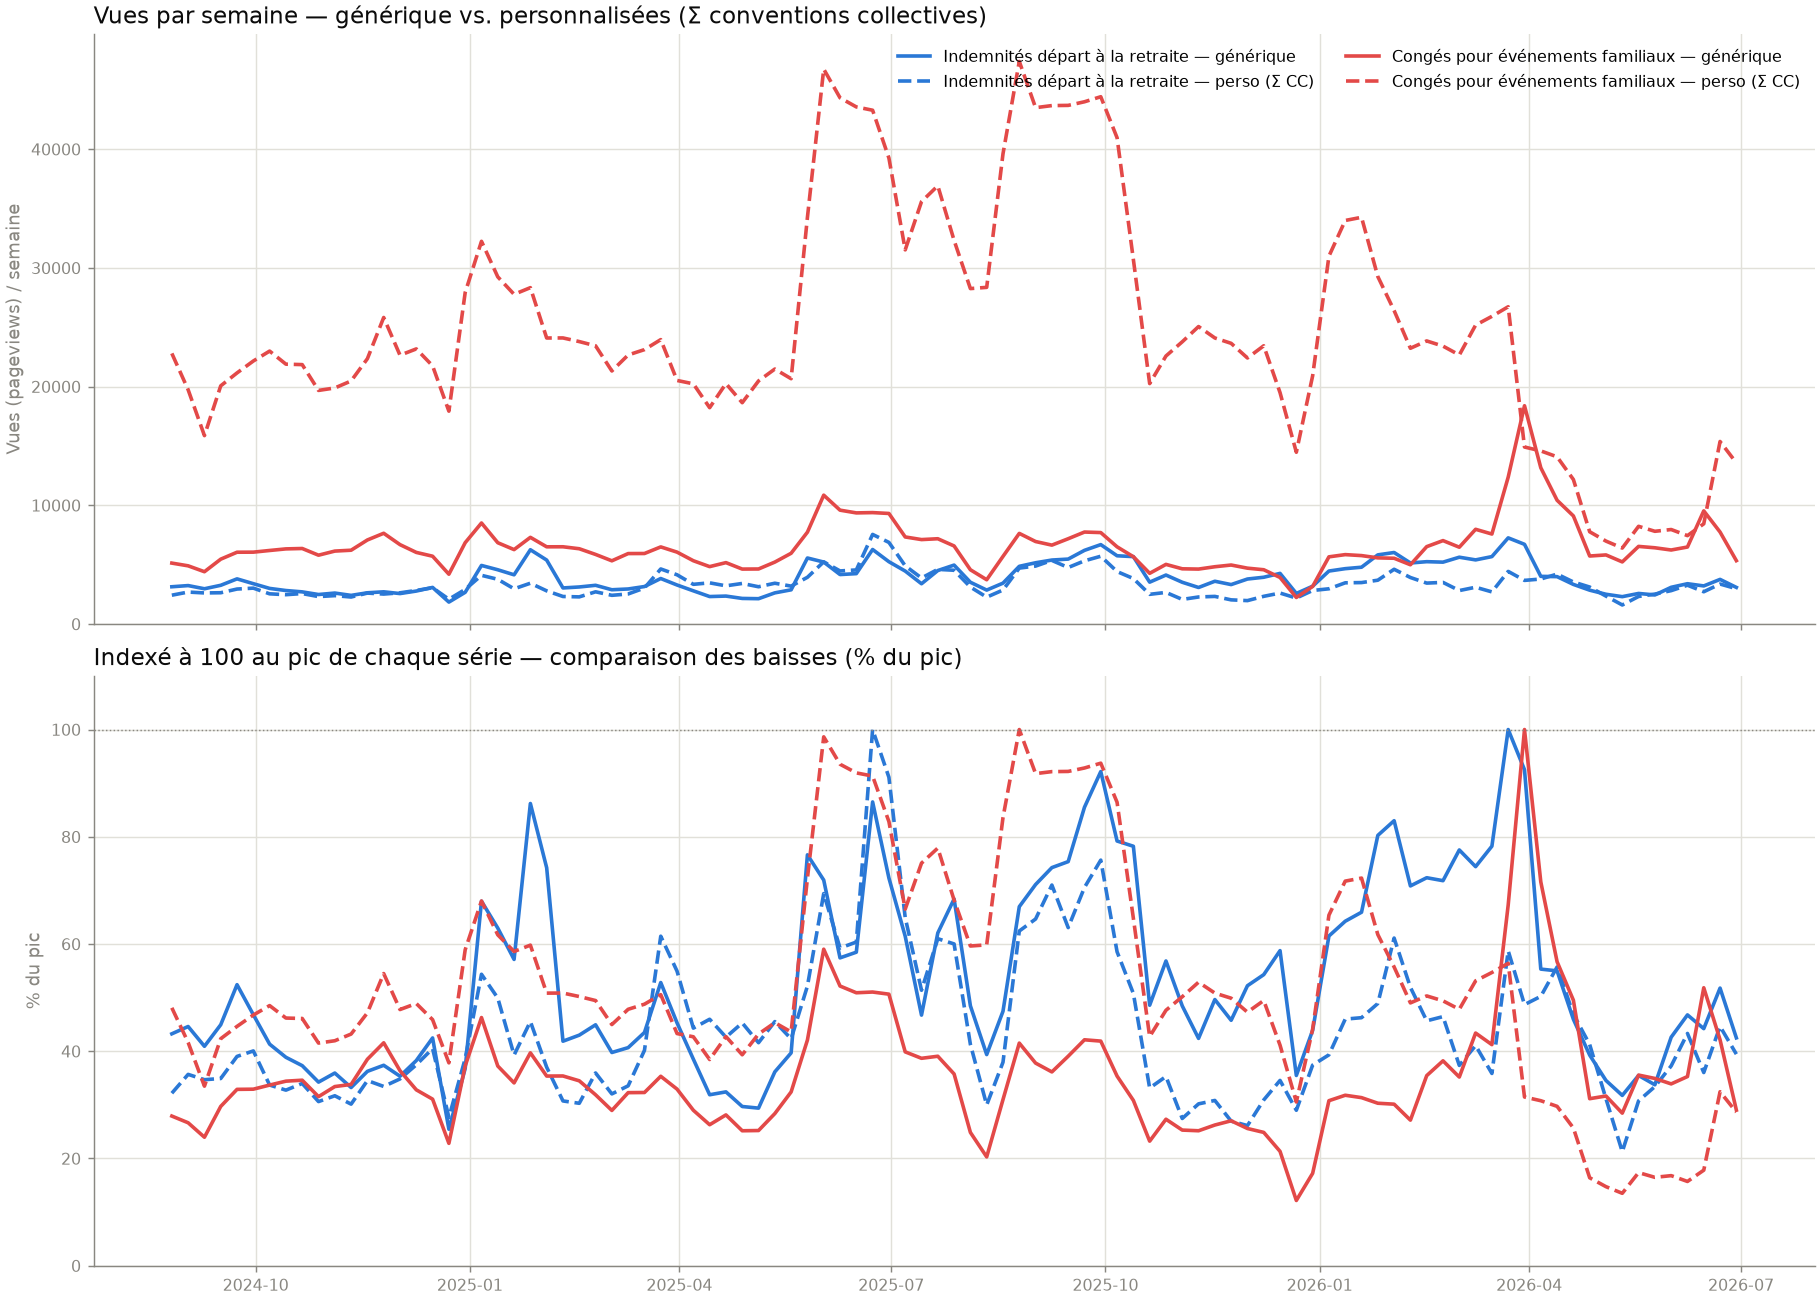

In [5]:
from pathlib import Path

from IPython.display import Image

out = Path("../output")
out.mkdir(parents=True, exist_ok=True)
png = out / "contrib_weekly_playground.png"
build_chart(df, metric_label, png)
Image(str(png))

## Aller plus loin

- **Changer de métrique :** `METRIC = "visits"` dans les paramètres.
- **Suivre une autre contribution :** ajoute une entrée à `CONTRIBUTIONS` (voir
  `analysis/src/analysis/reports/contrib_weekly_views.py`) avec sa `generic_slug`
  et une couleur, puis relance. Le matching plat + imbriqué s'applique automatiquement.
- **Exporter :** `df.to_csv("../output/mon_export.csv", index=False)`.
- **Inspecter une semaine brute :** `weeks[list(weeks)[-1]][:5]`.